# Day 6: Continuous Probability Distributions — Comprehensive Master Lab
### Course: Data Analytics (CDAC PGCP-AI)

This master laboratory provides a rigorous, visual, and applied deep-dive into **all major continuous probability distributions** in Data Science, Machine Learning, and Business Analytics, with dedicated analysis of **where, why, and how each distribution is used in industry**.

**Structured Modules Covered:**
1. **Fundamental Symmetric & Baseline:** Normal (Gaussian), Standard Normal $\mathcal{Z}$, Continuous Uniform
2. **Skewed, Lifetime & Waiting Times:** Exponential, Gamma, Weibull, Log-Normal, Pareto (Power-Law)
3. **Inferential & Hypothesis Testing:** Student's t, Chi-Square ($\chi^2$), F-Distribution (ANOVA)
4. **Bounded Interval Modeling:** Beta Distribution ($x \in [0, 1]$), Triangular Distribution (PERT/Risk)
5. **Heavy-Tailed & Specialized:** Laplace (Double Exponential / L1 Lasso), Cauchy (Lorentzian), Logistic
6. **Statistical Model Selection & Goodness-of-Fit:** Maximum Likelihood Fitting & Kolmogorov-Smirnov (K-S) Testing
7. **Master Enterprise Matrix:** Industry Domain Mapping, Decision Tree & Selection Heuristics

---


In [1]:
# ==============================================================================
# STEP 0: ENVIRONMENT SETUP & MODERN NUMPY RANDOM GENERATOR API
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Visual configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Modern NumPy Generator API with deterministic seed for reproducibility
rng = np.random.default_rng(seed=42)

print("Environment initialized successfully for Day 6 Continuous Probability Distributions!")
print(f"NumPy Version : {np.__version__}")
print(f"Pandas Version: {pd.__version__}")


Environment initialized successfully for Day 6 Continuous Probability Distributions!
NumPy Version : 2.4.6
Pandas Version: 2.2.3


## 1. Fundamental Symmetric & Baseline Distributions

### 1.1 The Normal (Gaussian) Distribution: $\mathcal{N}(\mu, \sigma^2)$
By the **Central Limit Theorem (CLT)**, the sum or mean of a large number of independent random variables converges to a Gaussian distribution, regardless of their underlying shape.

**Probability Density Function (PDF):**
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right), \quad x \in (-\infty, \infty)$$

**The Empirical 68-95-99.7 Rule:**
- $P(\mu - 1\sigma \le X \le \mu + 1\sigma) \approx 68.27\%$
- $P(\mu - 2\sigma \le X \le \mu + 2\sigma) \approx 95.45\%$
- $P(\mu - 3\sigma \le X \le \mu + 3\sigma) \approx 99.73\%$

#### 🏢 Where It Is Used in Industry & AI:
1. **Six Sigma Manufacturing & Industrial Quality Control (Motorola, GE, Toyota):** Parts dimensions (e.g. semiconductor wafer thickness, ball bearing diameters). At $6\sigma$ tolerance limits, defect rates are driven below **3.4 parts per million**.
2. **Classical Machine Learning:** Standard assumption in **Ordinary Least Squares (OLS)** linear regression residuals, Gaussian Naive Bayes classification, and Kalman Filtering in autonomous robotics.
3. **Deep Learning Weight Initialization:** He-Normal and Xavier-Normal initializations draw neural network weights from a truncated Gaussian to prevent exploding/vanishing gradients.
4. **Financial Asset Returns & Risk Analysis:** Modern Portfolio Theory (Markowitz mean-variance optimization) models short-term asset returns as Gaussian.

---

### 1.2 The Standard Normal Distribution: $\mathcal{Z} \sim \mathcal{N}(0, 1)$
Standardized form with $\mu = 0$ and $\sigma = 1$, computed via the Z-Score transform: $Z = \frac{X - \mu}{\sigma}$.

#### 🏢 Where It Is Used in Industry & AI:
1. **Feature Scaling in ML (`StandardScaler` in Scikit-Learn):** Centers and standardizes feature columns so distance-based algorithms (KNN, SVM, K-Means) and Gradient Descent treat features equitably.
2. **Z-Score Outlier Detection:** Flagging transactions or sensor readings with $|Z| > 3$ ($99.73\%$ boundary) for automated fraud alerts and data sanitization.

---

### 1.3 The Continuous Uniform Distribution: $\mathcal{U}(a, b)$
Assigns equal probability density across every point in $[a, b]$: $f(x) = \frac{1}{b - a}$. Represents maximum entropy (complete lack of bias) over a bounded interval.

#### 🏢 Where It Is Used in Industry & AI:
1. **Hyperparameter Optimization (`RandomizedSearchCV`):** Sampling learning rates $\eta \in [0.001, 0.1]$ and dropout probabilities uniformly.
2. **Monte Carlo Simulations & Sampling Engines:** The bedrock of pseudo-random number generation. Any continuous distribution can be sampled by applying the inverse CDF to a uniform draw: $X = F^{-1}(U)$ where $U \sim \mathcal{U}(0, 1)$.


      INDUSTRY APPLICATION: SIX SIGMA PRECISION TOLERANCE & DEFECT RATE       
Target Nominal Diameter          : 50.00 mm
Standard Deviation (sigma)       : 0.0500 mm
3-Sigma Tolerance Window         : [49.850, 50.150] mm
Simulated Parts Evaluated        : 100,000
Parts Outside 3-Sigma Limits     : 301 defects
Empirical Defect Rate            : 3010.0 Parts Per Million (PPM) (Theoretical: ~2,700 PPM)


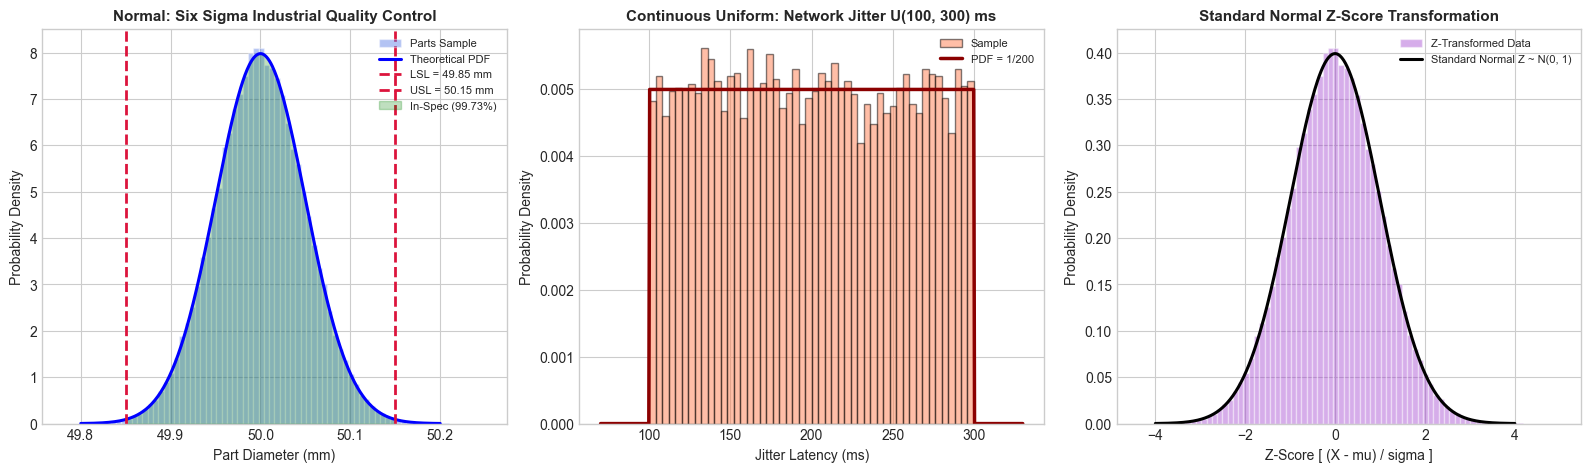

In [3]:
# ==============================================================================
# SECTION 1 CODE: GAUSSIAN SIX SIGMA QUALITY CONTROL & UNIFORM SIMULATION
# ==============================================================================
# 1. Industrial Simulation: Precision Machining Part Diameters (mu=50.0mm, sigma=0.05mm)
mu_part, sigma_part = 50.0, 0.05
N_parts = 100000
parts_sample = rng.normal(loc=mu_part, scale=sigma_part, size=N_parts)

# 2. Six Sigma Quality Control Evaluation (Tolerance bounds: [49.85mm, 50.15mm] = +/- 3 sigma)
usl = mu_part + 3 * sigma_part  # Upper Specification Limit
lsl = mu_part - 3 * sigma_part  # Lower Specification Limit
defects = np.sum((parts_sample < lsl) | (parts_sample > usl))
defect_rate_ppm = (defects / N_parts) * 1e6

# 3. Continuous Uniform Simulation: Server Request Timeout Jitter (U(100ms, 300ms))
a_jitter, b_jitter = 100.0, 300.0
jitter_sample = rng.uniform(low=a_jitter, high=b_jitter, size=10000)

print("=" * 80)
print("      INDUSTRY APPLICATION: SIX SIGMA PRECISION TOLERANCE & DEFECT RATE       ")
print("=" * 80)
print(f"Target Nominal Diameter          : {mu_part:.2f} mm")
print(f"Standard Deviation (sigma)       : {sigma_part:.4f} mm")
print(f"3-Sigma Tolerance Window         : [{lsl:.3f}, {usl:.3f}] mm")
print(f"Simulated Parts Evaluated        : {N_parts:,}")
print(f"Parts Outside 3-Sigma Limits     : {defects} defects")
print(f"Empirical Defect Rate            : {defect_rate_ppm:.1f} Parts Per Million (PPM) (Theoretical: ~2,700 PPM)")
print("=" * 80)

# 4. Visualizations: Six Sigma Normal vs. Uniform
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Subplot 1: Six Sigma Normal Distribution with Tolerances
x_norm_grid = np.linspace(mu_part - 4*sigma_part, mu_part + 4*sigma_part, 500)
pdf_norm = stats.norm.pdf(x_norm_grid, mu_part, sigma_part)
axes[0].hist(parts_sample, bins=80, density=True, alpha=0.4, color='royalblue', edgecolor='white', label='Parts Sample')
axes[0].plot(x_norm_grid, pdf_norm, 'b-', lw=2.2, label='Theoretical PDF')
axes[0].axvline(lsl, color='crimson', linestyle='--', lw=2.0, label=f'LSL = {lsl:.2f} mm')
axes[0].axvline(usl, color='crimson', linestyle='--', lw=2.0, label=f'USL = {usl:.2f} mm')
axes[0].fill_between(x_norm_grid, pdf_norm, where=(x_norm_grid >= lsl) & (x_norm_grid <= usl),
                     color='green', alpha=0.25, label='In-Spec (99.73%)')
axes[0].set_title('Normal: Six Sigma Industrial Quality Control', fontweight='bold')
axes[0].set_xlabel('Part Diameter (mm)'); axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=8, loc='upper right')

# Subplot 2: Continuous Uniform Distribution (Network Jitter)
x_uni_grid = np.linspace(a_jitter - 30, b_jitter + 30, 500)
pdf_uni = stats.uniform.pdf(x_uni_grid, loc=a_jitter, scale=b_jitter - a_jitter)
axes[1].hist(jitter_sample, bins=50, density=True, alpha=0.5, color='coral', edgecolor='black', label='Sample')
axes[1].plot(x_uni_grid, pdf_uni, color='darkred', lw=2.5, label=f'PDF = 1/{b_jitter-a_jitter:.0f}')
axes[1].set_title(f'Continuous Uniform: Network Jitter U({a_jitter:.0f}, {b_jitter:.0f}) ms', fontweight='bold')
axes[1].set_xlabel('Jitter Latency (ms)'); axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8, loc='upper right')

# Subplot 3: Z-Score Transformation (Standard Normal Z ~ N(0, 1))
z_scores = (parts_sample - mu_part) / sigma_part
x_z_grid = np.linspace(-4, 4, 400)
axes[2].hist(z_scores, bins=80, density=True, alpha=0.4, color='darkorchid', edgecolor='white', label='Z-Transformed Data')
axes[2].plot(x_z_grid, stats.norm.pdf(x_z_grid, 0, 1), 'k-', lw=2.2, label='Standard Normal Z ~ N(0, 1)')
axes[2].set_title('Standard Normal Z-Score Transformation', fontweight='bold')
axes[2].set_xlabel('Z-Score [ (X - mu) / sigma ]'); axes[2].set_ylabel('Probability Density')
axes[2].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


## 2. Skewed, Lifetime & Waiting-Time Distributions (Non-Negative Support $[0, \infty)$)

Values in real operations (time, money, size, intensity) cannot be negative and often exhibit heavy positive skew.

### 2.1 Exponential Distribution: $\text{Exp}(\lambda)$
- Models the **time elapsed between independent Poisson event arrivals** under constant rate $\lambda$.
- **Memoryless Property:** $P(X > s + t \mid X > s) = P(X > t)$. Prior survival time conveys zero information about the remaining time until the next event.
- **🏢 Where It Is Used in Industry & AI:**
  1. **Site Reliability Engineering (SRE) & Cloud Infrastructure (AWS, Google Cloud):** Modeling **Mean Time Between Failures (MTBF)** of cloud VM instances and hard disk drives.
  2. **Telecommunications & Customer Support:** Wait times between incoming calls to a call center or API endpoint requests.
  3. **Healthcare & Pharmacology:** Drug elimination half-lives and radioactive isotope decay in nuclear medicine.

---

### 2.2 Gamma Distribution: $\text{Gamma}(k, \theta)$
- Represents the **sum of $k$ independent exponential waiting times** with scale $\theta = 1/\lambda$.
- **🏢 Where It Is Used in Industry & AI:**
  1. **Multi-Stage Queuing Systems (Banking, Fast-Food, E-commerce):** Total customer processing time across sequential service checkpoints (e.g. order -> preparation -> packaging -> delivery).
  2. **Insurance & Actuarial Risk Analysis:** Total aggregate dollar claims resulting from severe weather or industrial accidents.
  3. **Bayesian Machine Learning:** The mathematical **conjugate prior for the Poisson rate $\lambda$**, allowing analytical updates of customer arrival rates without numerical integration.

---

### 2.3 Weibull Distribution: $\text{Weibull}(k, \lambda)$
- Governed by the **Shape Parameter $k$**, enabling it to model all 3 phases of the engineering **Bathtub Hazard Curve**:
  - $k < 1$: **Decreasing failure rate** ("Infant mortality" — manufacturing defects weeded out early).
  - $k = 1$: **Constant failure rate** (collapses exactly to the **Exponential** distribution).
  - $k > 1$: **Increasing failure rate** (mechanical wear-out, thermal fatigue, aging).
- **🏢 Where It Is Used in Industry & AI:**
  1. **Aerospace & Mechanical Reliability (Boeing, GE Aerospace):** Predicting jet engine turbine blade lifespan, ball bearing wear, and scheduling preventive maintenance.
  2. **Renewable Energy Engineering:** Modeling wind speed distributions to optimize wind turbine site selection and annual power generation forecasts.

---

### 2.4 Log-Normal Distribution: $\text{Lognormal}(\mu, \sigma)$
- Arises when random variables are the **product** (multiplicative compounding) of many independent factors (Gibrat's Law).
- **🏢 Where It Is Used in Industry & AI:**
  1. **Quantitative Finance & Stock Options:** The **Black-Scholes-Merton Options Pricing Model** assumes stock prices follow a Log-Normal distribution because prices are strictly positive and compound multiplicatively.
  2. **Tech & Streaming Platforms (Netflix, Spotify, YouTube):** API latency, server response time percentiles (p95, p99), and video buffering duration.
  3. **Economics & Demographics:** National household income and wealth distributions (preventing negative income while modeling high-net-worth outliers).

---

### 2.5 Pareto Distribution: $\text{Pareto}(\alpha, x_m)$
- Models **Power-Law phenomena** and the **80/20 Rule** ($f(x) \propto x^{-(\alpha+1)}$).
- **🏢 Where It Is Used in Industry & AI:**
  1. **E-Commerce & Retail (Amazon, Walmart):** The Long Tail — $80\%$ of sales revenue is driven by $20\%$ of catalog products; $80\%$ of web traffic originates from $20\%$ of domains.
  2. **Cybersecurity & Network Traffic:** Distributed Denial of Service (DDoS) traffic spikes and file size transfers over the public internet.
  3. **Seismology & Insurance:** The Gutenberg-Richter law for earthquake intensities and catastrophic flood damage payouts.


       SKEWED DISTRIBUTIONS: THEORETICAL MOMENTS & PRIMARY INDUSTRY DOMAINS       
Distribution                Mean                     Variance                                                  Primary Industry Domain
 Exponential            1/lambda                   1/lambda^2                   Cloud SRE (MTBF), Customer Call Centers, Physics Decay
       Gamma             k*theta                    k*theta^2  Multi-checkpoint Queuing, Insurance Loss Claims, Bayesian Poisson Prior
     Weibull lambda*Gamma(1+1/k)                      Complex             Aerospace Jet Engine Lifespan, Wind Turbine Power Generation
  Log-Normal     exp(mu+sig^2/2) exp(2mu+sig^2)(exp(sig^2)-1) Black-Scholes Stock Prices, Netflix Server p99 Latency, Household Wealth
      Pareto  alpha*xm/(alpha-1)    alpha*xm^2/((a-1)^2(a-2))          80/20 Rule in Retail Catalog Sales, DDoS Attack Traffic Volumes


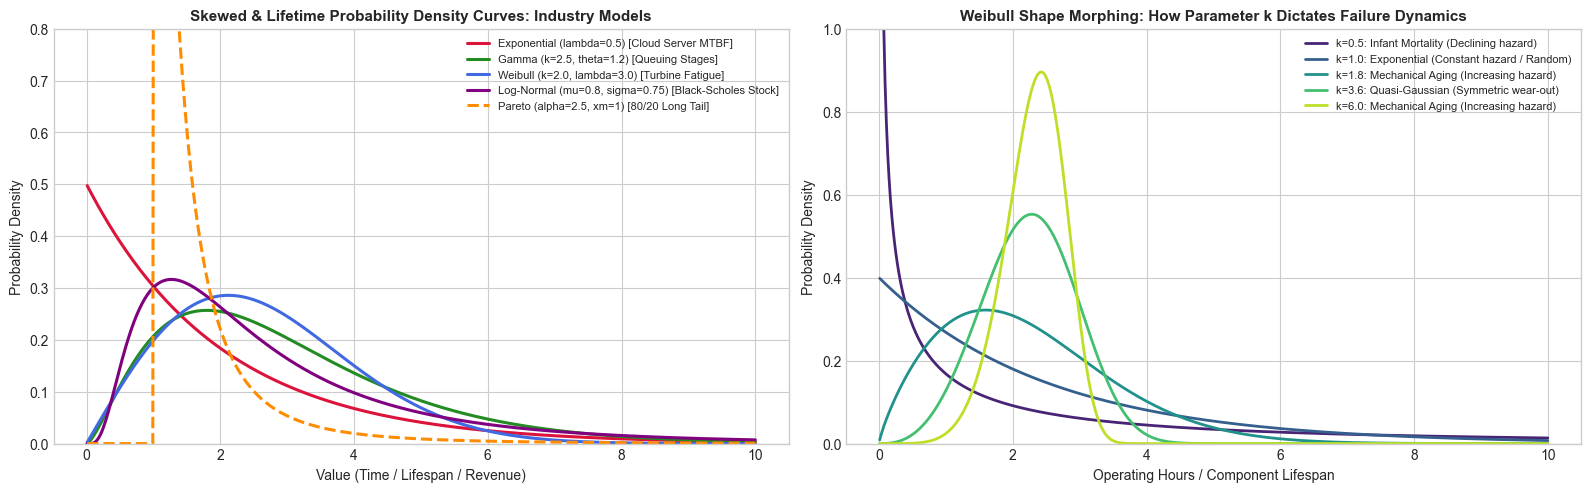

In [5]:
# ==============================================================================
# SECTION 2 CODE: SKEWED & LIFETIME FAMILY VISUALIZATION & INDUSTRY METRICS
# ==============================================================================
x_eval = np.linspace(0.01, 10.0, 500)

# 1. Compute Analytical PDFs across all 5 Skewed Distributions
pdf_expon = stats.expon.pdf(x_eval, scale=2.0)                 # lambda = 0.5, mean = 2.0
pdf_gamma = stats.gamma.pdf(x_eval, a=2.5, scale=1.2)          # k=2.5, theta=1.2
pdf_weibull_aging = stats.weibull_min.pdf(x_eval, c=2.0, scale=3.0) # k=2.0 (aging wear-out)
pdf_lognorm = stats.lognorm.pdf(x_eval, s=0.75, scale=np.exp(0.8))   # sigma=0.75, mu=0.8
pdf_pareto = stats.pareto.pdf(x_eval, b=2.5, scale=1.0)        # alpha=2.5, xm=1.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Cross-Family Comparison of Density Curves
axes[0].plot(x_eval, pdf_expon, color='crimson', lw=2.2, label='Exponential (lambda=0.5) [Cloud Server MTBF]')
axes[0].plot(x_eval, pdf_gamma, color='forestgreen', lw=2.2, label='Gamma (k=2.5, theta=1.2) [Queuing Stages]')
axes[0].plot(x_eval, pdf_weibull_aging, color='royalblue', lw=2.2, label='Weibull (k=2.0, lambda=3.0) [Turbine Fatigue]')
axes[0].plot(x_eval, pdf_lognorm, color='purple', lw=2.2, label='Log-Normal (mu=0.8, sigma=0.75) [Black-Scholes Stock]')
axes[0].plot(x_eval, pdf_pareto, color='darkorange', lw=2.2, linestyle='--', label='Pareto (alpha=2.5, xm=1) [80/20 Long Tail]')
axes[0].set_ylim(0, 0.8)
axes[0].set_title('Skewed & Lifetime Probability Density Curves: Industry Models', fontweight='bold')
axes[0].set_xlabel('Value (Time / Lifespan / Revenue)'); axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=8, loc='upper right')

# Subplot 2: Weibull Bathtub Hazard Morphing (Infant Mortality -> Constant -> Aging)
k_values = [0.5, 1.0, 1.8, 3.6, 6.0]
colors_k = plt.cm.viridis(np.linspace(0.1, 0.9, len(k_values)))
for k_val, col in zip(k_values, colors_k):
    pdf_w = stats.weibull_min.pdf(x_eval, c=k_val, scale=2.5)
    lbl = f'k={k_val}: '
    if k_val < 1: lbl += 'Infant Mortality (Declining hazard)'
    elif k_val == 1: lbl += 'Exponential (Constant hazard / Random)'
    elif np.isclose(k_val, 3.6): lbl += 'Quasi-Gaussian (Symmetric wear-out)'
    else: lbl += 'Mechanical Aging (Increasing hazard)'
    axes[1].plot(x_eval, pdf_w, color=col, lw=2.0, label=lbl)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Weibull Shape Morphing: How Parameter k Dictates Failure Dynamics', fontweight='bold')
axes[1].set_xlabel('Operating Hours / Component Lifespan'); axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# Print Industry Summary Table
print("=" * 95)
print("       SKEWED DISTRIBUTIONS: THEORETICAL MOMENTS & PRIMARY INDUSTRY DOMAINS       ")
print("=" * 95)
skew_summary = pd.DataFrame([
    {'Distribution': 'Exponential', 'Mean': '1/lambda', 'Variance': '1/lambda^2', 'Primary Industry Domain': 'Cloud SRE (MTBF), Customer Call Centers, Physics Decay'},
    {'Distribution': 'Gamma', 'Mean': 'k*theta', 'Variance': 'k*theta^2', 'Primary Industry Domain': 'Multi-checkpoint Queuing, Insurance Loss Claims, Bayesian Poisson Prior'},
    {'Distribution': 'Weibull', 'Mean': 'lambda*Gamma(1+1/k)', 'Variance': 'Complex', 'Primary Industry Domain': 'Aerospace Jet Engine Lifespan, Wind Turbine Power Generation'},
    {'Distribution': 'Log-Normal', 'Mean': 'exp(mu+sig^2/2)', 'Variance': 'exp(2mu+sig^2)(exp(sig^2)-1)', 'Primary Industry Domain': 'Black-Scholes Stock Prices, Netflix Server p99 Latency, Household Wealth'},
    {'Distribution': 'Pareto', 'Mean': 'alpha*xm/(alpha-1)', 'Variance': 'alpha*xm^2/((a-1)^2(a-2))', 'Primary Industry Domain': '80/20 Rule in Retail Catalog Sales, DDoS Attack Traffic Volumes'}
])
print(skew_summary.to_string(index=False))
print("=" * 95)


## 3. Inferential & Hypothesis Testing Distributions

These continuous distributions form the mathematical engine of **A/B Testing, Feature Selection, Clinical Trials, and Machine Learning Model Diagnostics**.

### 3.1 Student's t-Distribution: $t(\nu)$
- **The Problem it Solves:** When evaluating a sample mean from small sample sizes ($n < 30$), the true population variance $\sigma^2$ is unknown and must be estimated via sample variance $s^2$. The resulting statistic follows a Student's t-distribution with $\nu = n - 1$ degrees of freedom.
- **Characteristics:** Symmetric with heavier tails than Gaussian. As $\nu \to \infty$, $t(\nu) \to \mathcal{N}(0, 1)$.
- **🏢 Where It Is Used in Industry & AI:**
  1. **A/B Testing for Digital Products (Meta, Google, Amazon):** Two-sample $t$-test comparing user conversion rates between Control and Variant UI designs when traffic volume is moderate.
  2. **Financial Risk & Value-at-Risk (VaR):** Modeling stock return distributions with heavier tails than Gaussian to protect investment funds against sudden market shocks.
  3. **Robust Machine Learning & Dimensionality Reduction:** The core foundation of **t-SNE (t-Distributed Stochastic Neighbor Embedding)**, which uses a Student-t kernel to prevent crowding of high-dimensional clusters.

---

### 3.2 Chi-Square Distribution: $\chi^2(k)$
- **Definition:** The sum of $k$ independent squared standard normal variables: $Q = \sum_{i=1}^k Z_i^2 \sim \chi^2(k)$.
- **🏢 Where It Is Used in Industry & AI:**
  1. **Feature Selection in NLP & Tabular ML (`SelectKBest(chi2)` in Scikit-Learn):** Measures statistical dependence between categorical input features and target labels to filter out non-informative columns.
  2. **Goodness-of-Fit Tests:** Testing whether survey response distributions or customer churn patterns match theoretical expectations.
  3. **Contingency Table Testing (`scipy.stats.chi2_contingency`):** Determining if customer device type (iOS vs. Android) is statistically independent of subscription renewal rates.

---

### 3.3 Fisher-Snedecor F-Distribution: $F(d_1, d_2)$
- **Definition:** The ratio of two independent Chi-Square variables, each normalized by its degrees of freedom: $F = \frac{\chi_1^2 / d_1}{\chi_2^2 / d_2}$.
- **🏢 Where It Is Used in Industry & AI:**
  1. **ANOVA (Analysis of Variance) in Clinical & Marketing Trials:** Testing whether there is a statistically significant difference across $>2$ marketing campaigns or drug treatment dosages simultaneously without inflating false-positive rates.
  2. **Multiple Linear Regression Model Diagnostics:** The overall model significance $F$-test evaluates $H_0: \beta_1 = \beta_2 = \dots = \beta_p = 0$ ($R^2 = 0$).
  3. **Homoscedasticity Testing:** Goldfeld-Quandt test for verifying whether error variance remains constant across sub-populations.


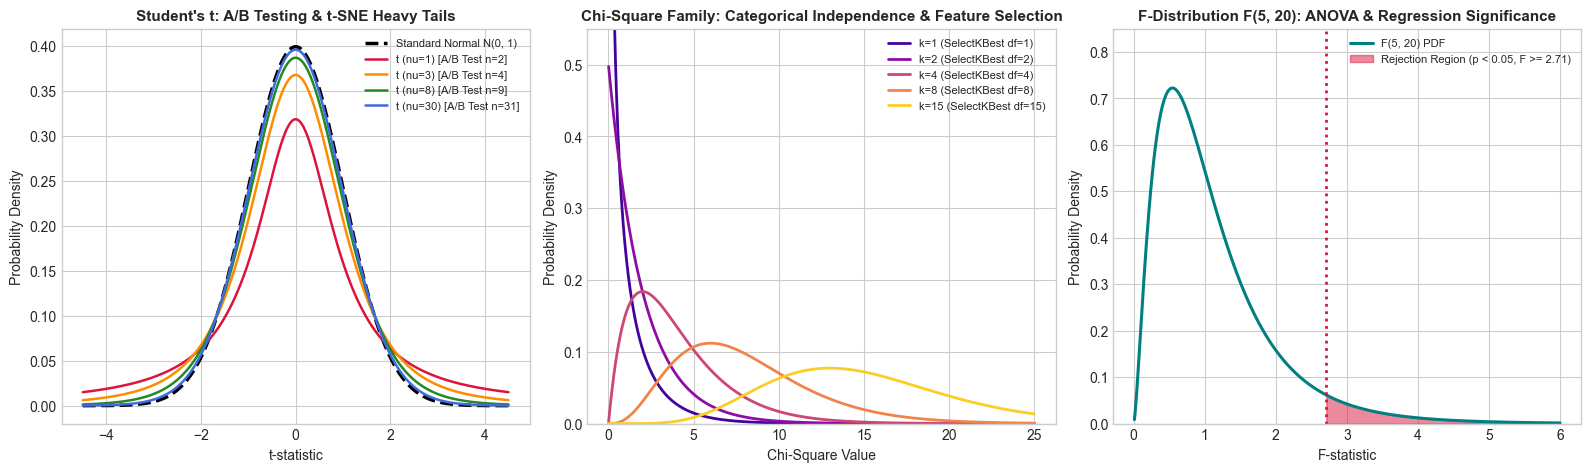

In [7]:
# ==============================================================================
# SECTION 3 CODE: INFERENTIAL SAMPLING DISTRIBUTIONS & CRITICAL REGIONS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Subplot 1: Student's t Convergence to Normal (Heavy Tail Protection)
x_t = np.linspace(-4.5, 4.5, 500)
axes[0].plot(x_t, stats.norm.pdf(x_t), color='black', lw=2.5, linestyle='--', label='Standard Normal N(0, 1)')
for nu_val, col in zip([1, 3, 8, 30], ['crimson', 'darkorange', 'forestgreen', 'royalblue']):
    pdf_t = stats.t.pdf(x_t, df=nu_val)
    axes[0].plot(x_t, pdf_t, color=col, lw=1.8, label=f't (nu={nu_val}) [A/B Test n={nu_val+1}]')
axes[0].set_title("Student's t: A/B Testing & t-SNE Heavy Tails", fontweight='bold')
axes[0].set_xlabel('t-statistic'); axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=8, loc='upper right')

# Subplot 2: Chi-Square Family: Feature Selection & Independence
x_chi = np.linspace(0.01, 25.0, 500)
for k_val, col in zip([1, 2, 4, 8, 15], plt.cm.plasma(np.linspace(0.1, 0.9, 5))):
    axes[1].plot(x_chi, stats.chi2.pdf(x_chi, df=k_val), color=col, lw=2.0, label=f'k={k_val} (SelectKBest df={k_val})')
axes[1].set_ylim(0, 0.55)
axes[1].set_title('Chi-Square Family: Categorical Independence & Feature Selection', fontweight='bold')
axes[1].set_xlabel('Chi-Square Value'); axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8, loc='upper right')

# Subplot 3: F-Distribution and Critical Rejection Region (alpha = 0.05)
x_f = np.linspace(0.01, 6.0, 500)
d1, d2 = 5, 20
pdf_f = stats.f.pdf(x_f, dfn=d1, dfd=d2)
crit_val = stats.f.ppf(0.95, dfn=d1, dfd=d2)  # Critical threshold for alpha = 0.05
axes[2].plot(x_f, pdf_f, color='teal', lw=2.2, label=f'F({d1}, {d2}) PDF')
axes[2].fill_between(x_f, pdf_f, where=(x_f >= crit_val), color='crimson', alpha=0.5,
                     label=f'Rejection Region (p < 0.05, F >= {crit_val:.2f})')
axes[2].axvline(crit_val, color='crimson', linestyle=':', lw=2.0)
axes[2].set_ylim(0, 0.85)
axes[2].set_title(f'F-Distribution F({d1}, {d2}): ANOVA & Regression Significance', fontweight='bold')
axes[2].set_xlabel('F-statistic'); axes[2].set_ylabel('Probability Density')
axes[2].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


## 4. Bounded Interval Modeling: Proportions & Business Risk

### 4.1 The Beta Distribution: $\text{Beta}(\alpha, \beta)$ on $[0, 1]$
- Supported strictly on the closed interval $[0, 1]$, making it the natural mathematical model for **probabilities, percentages, and proportions**.
- Depending on parameters $\alpha$ and $\beta$, it morphs from U-shaped to uniform, symmetric bell, or highly skewed.
- **🏢 Where It Is Used in Industry & AI:**
  1. **Multi-Armed Bandit Algorithms & Reinforcement Learning (Netflix, Spotify):** **Thompson Sampling** dynamically allocates traffic to the best-performing recommendation algorithms by sampling from their Beta posterior distributions.
  2. **Bayesian A/B Testing in E-Commerce:** Modeling user conversion rates. If 20 conversions occur in 100 trials, the posterior is updated cleanly as $\text{Beta}(\alpha + 20, \beta + 80)$ without approximations.
  3. **Clinical Trial Success Rates:** Modeling drug efficacy probabilities in Phase II pharmaceutical trials.

---

### 4.2 The Triangular Distribution: $\text{Triangular}(a, c, b)$ on $[a, b]$
- Defined by three intuitive values: Minimum ($a$), Mode / Most Likely ($c$), and Maximum ($b$).
- **🏢 Where It Is Used in Industry & AI:**
  1. **Project Management (PERT / CPM) (Construction, Aerospace Bidding, Software Sprints):** Estimating task completion schedules when historical data does not exist, but domain engineers can provide Optimistic ($a$), Most Likely ($c$), and Pessimistic ($b$) estimates.
  2. **Corporate Financial Risk & Capital Budgeting:** Simulating future raw material costs and exchange rates in Monte Carlo decision models.


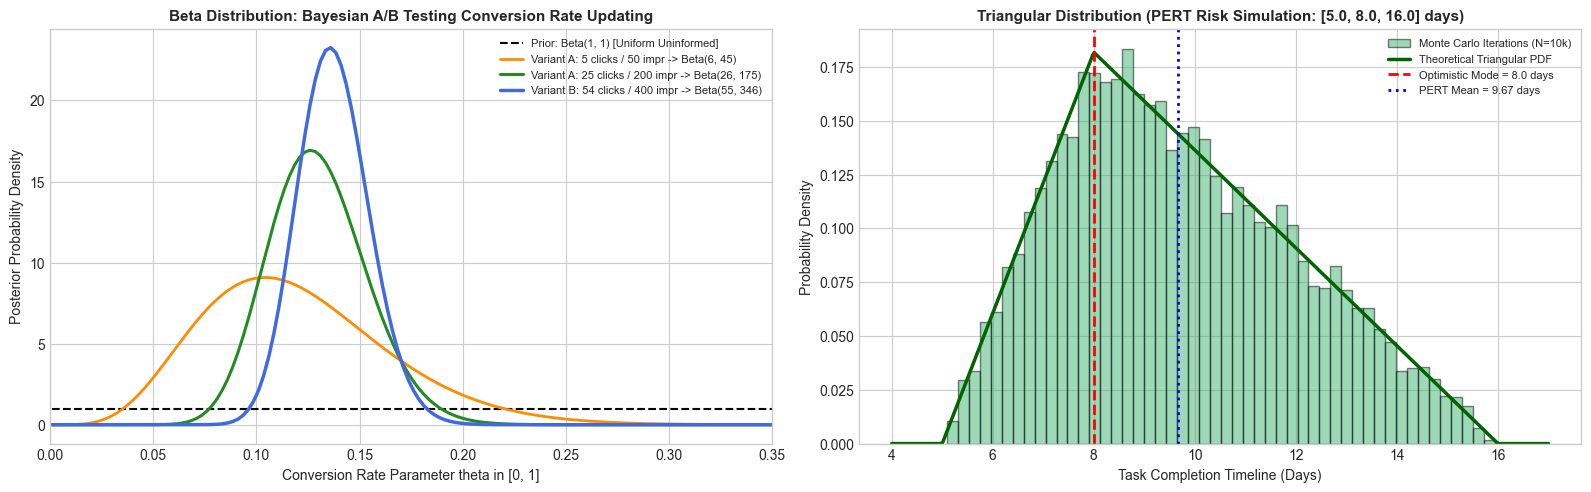

In [9]:
# ==============================================================================
# SECTION 4 CODE: BAYESIAN CONVERSION UPDATING & PERT RISK SIMULATION
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: The Beta Distribution (Bayesian A/B Testing Conversion Rate Evolution)
x_beta = np.linspace(0.001, 0.999, 400)
axes[0].plot(x_beta, stats.beta.pdf(x_beta, 1, 1), 'k--', lw=1.5, label='Prior: Beta(1, 1) [Uniform Uninformed]')
axes[0].plot(x_beta, stats.beta.pdf(x_beta, 6, 44), color='darkorange', lw=2.0, label='Variant A: 5 clicks / 50 impr -> Beta(6, 45)')
axes[0].plot(x_beta, stats.beta.pdf(x_beta, 26, 174), color='forestgreen', lw=2.2, label='Variant A: 25 clicks / 200 impr -> Beta(26, 175)')
axes[0].plot(x_beta, stats.beta.pdf(x_beta, 55, 345), color='royalblue', lw=2.5, label='Variant B: 54 clicks / 400 impr -> Beta(55, 346)')
axes[0].set_xlim(0, 0.35)
axes[0].set_title('Beta Distribution: Bayesian A/B Testing Conversion Rate Updating', fontweight='bold')
axes[0].set_xlabel('Conversion Rate Parameter theta in [0, 1]'); axes[0].set_ylabel('Posterior Probability Density')
axes[0].legend(fontsize=8, loc='upper right')

# Subplot 2: Triangular Distribution (Project Duration Simulation: a=5 days, c=8 days, b=16 days)
a_tri, c_tri, b_tri = 5.0, 8.0, 16.0
sample_tri = rng.triangular(left=a_tri, mode=c_tri, right=b_tri, size=10000)
x_tri = np.linspace(a_tri - 1, b_tri + 1, 400)
c_scaled = (c_tri - a_tri) / (b_tri - a_tri)
pdf_tri = stats.triang.pdf(x_tri, c=c_scaled, loc=a_tri, scale=b_tri - a_tri)

axes[1].hist(sample_tri, bins=50, density=True, color='mediumseagreen', alpha=0.5, edgecolor='black', label='Monte Carlo Iterations (N=10k)')
axes[1].plot(x_tri, pdf_tri, color='darkgreen', lw=2.5, label='Theoretical Triangular PDF')
axes[1].axvline(c_tri, color='red', linestyle='--', lw=2.0, label=f'Optimistic Mode = {c_tri} days')
axes[1].axvline(np.mean(sample_tri), color='blue', linestyle=':', lw=2.0, label=f'PERT Mean = {np.mean(sample_tri):.2f} days')
axes[1].set_title(f'Triangular Distribution (PERT Risk Simulation: [{a_tri}, {c_tri}, {b_tri}] days)', fontweight='bold')
axes[1].set_xlabel('Task Completion Timeline (Days)'); axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


## 5. Heavy-Tailed & Specialized Symmetric Distributions

### 5.1 Laplace Distribution (Double Exponential): $\text{Laplace}(\mu, b)$
- Formed by joining two back-to-back exponential distributions at $\mu$. Features a sharp, non-differentiable central peak and linear logarithmic tails.
- **🏢 Where It Is Used in Industry & AI:**
  1. **L1 Lasso Regularization in Machine Learning:** In Bayesian terms, performing Maximum A Posteriori (MAP) linear regression with a **Laplace prior on coefficients** is mathematically identical to adding an **L1 penalty** ($+\lambda \sum |\beta_j|$). This forces non-essential feature coefficients strictly to zero (automated feature selection).
  2. **Differential Privacy (Apple, Google, US Census):** The Laplace Mechanism adds calibrated noise drawn from $\text{Laplace}(0, \Delta f / \epsilon)$ to query outputs, providing formal mathematical privacy guarantees against database reconstruction attacks.
  3. **Speech & Audio Processing:** Raw acoustic wave pressure amplitudes exhibit sharp peaks near zero with heavier exponential tails.

---

### 5.2 Cauchy Distribution (Lorentzian): $\text{Cauchy}(x_0, \gamma)$
- Formed as the ratio of two independent standard normals: $Z_1 / Z_2$. Has **infinite variance and undefined mean**.
- **🏢 Where It Is Used in Industry & AI:**
  1. **Stress-Testing Optimization Algorithms:** Benchmarking gradient descent and stochastic optimizers to ensure they do not diverge when encountering massive impulse spikes.
  2. **Physics & Nuclear Spectroscopy:** Modeling the natural resonance line shape of decaying quantum states (Breit-Wigner distribution).
  3. **Financial Black Swan Stress-Testing:** Modeling extreme market dislocations where standard variance-based risk metrics (e.g. Sharpe ratio) fail completely.

---

### 5.3 Logistic Distribution: $\text{Logistic}(\mu, s)$
- Symmetrical with kurtosis = 1.2 (moderately fatter tails than Gaussian). Its CDF is the mathematical **Sigmoid Function**:
  $$F(x) = \frac{1}{1 + e^{-(x - \mu)/s}}$$
- **🏢 Where It Is Used in Industry & AI:**
  1. **Logistic Regression & Neural Networks:** The core link function converting continuous linear log-odds into probabilities ($P(Y=1|X) \in [0, 1]$).
  2. **Competitive Ranking Systems (Chess Elo, FIFA, Gaming Matchmaking):** The Elo rating system (used by Chess.com, Riot Games, Blizzard) models the probability of player A defeating player B via the Logistic distribution.


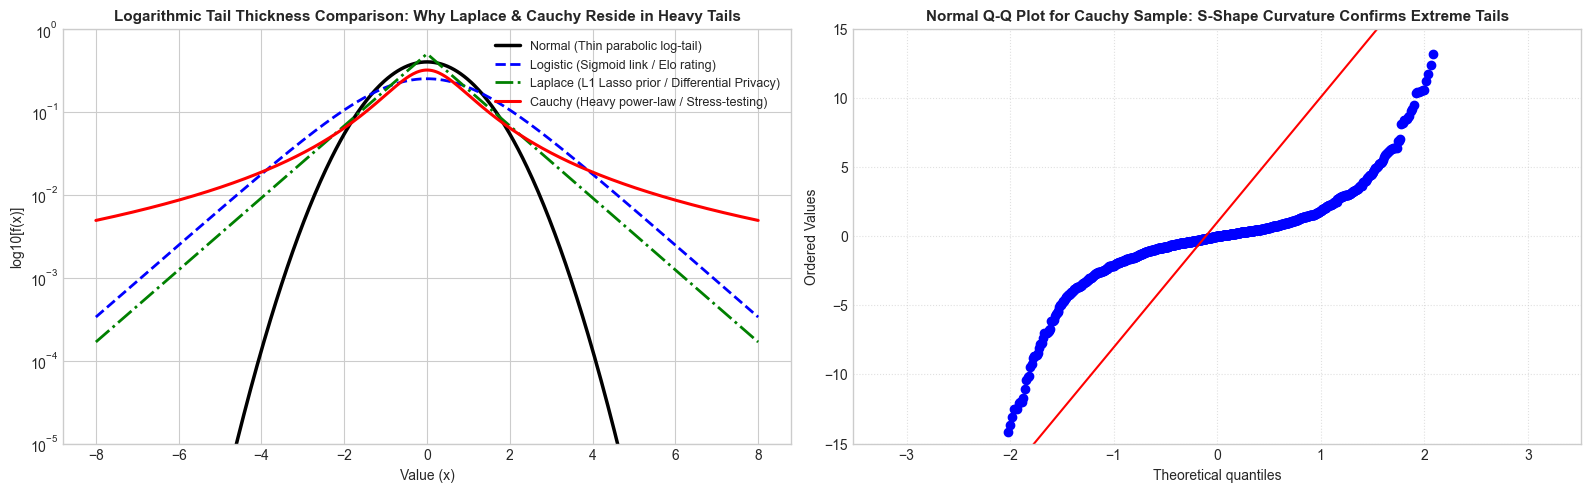

In [11]:
# ==============================================================================
# SECTION 5 CODE: LOG-DENSITY TAIL THICKNESS & DIFFERENTIAL PRIVACY NOISE
# ==============================================================================
x_tail = np.linspace(-8.0, 8.0, 600)

pdf_norm_tail = stats.norm.pdf(x_tail, 0, 1)
pdf_laplace_tail = stats.laplace.pdf(x_tail, 0, 1)
pdf_logistic_tail = stats.logistic.pdf(x_tail, 0, 1)
pdf_cauchy_tail = stats.cauchy.pdf(x_tail, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Tail Comparison on Logarithmic Density Scale (Reveals tail thickness)
axes[0].plot(x_tail, pdf_norm_tail, 'k-', lw=2.5, label='Normal (Thin parabolic log-tail)')
axes[0].plot(x_tail, pdf_logistic_tail, 'b--', lw=2.0, label='Logistic (Sigmoid link / Elo rating)')
axes[0].plot(x_tail, pdf_laplace_tail, 'g-.', lw=2.0, label='Laplace (L1 Lasso prior / Differential Privacy)')
axes[0].plot(x_tail, pdf_cauchy_tail, 'r-', lw=2.2, label='Cauchy (Heavy power-law / Stress-testing)')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-5, 1.0)
axes[0].set_title('Logarithmic Tail Thickness Comparison: Why Laplace & Cauchy Reside in Heavy Tails', fontweight='bold')
axes[0].set_xlabel('Value (x)'); axes[0].set_ylabel('log10[f(x)]')
axes[0].legend(fontsize=9, loc='upper right')

# Subplot 2: Q-Q Plot against Normal Reference (Revealing Heavy Tails)
sample_cauchy_test = stats.cauchy.rvs(loc=0, scale=1, size=1000, random_state=42)
stats.probplot(sample_cauchy_test, dist="norm", plot=axes[1])
axes[1].set_title('Normal Q-Q Plot for Cauchy Sample: S-Shape Curvature Confirms Extreme Tails', fontweight='bold')
axes[1].set_ylim(-15, 15)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 6. Statistical Model Selection: Distribution Fitting & K-S Testing

### How do Data Scientists select the correct continuous distribution for empirical data?

In production machine learning pipelines, assuming the wrong distribution leads to skewed predictions, invalid $p$-values, or failed anomaly detectors.

1. **Parametric Fitting via Maximum Likelihood Estimation (MLE):**
   SciPy's `stats.<dist>.fit(data)` optimizes distribution parameters to maximize the likelihood function $\mathcal{L}(\theta) = \prod_{i=1}^N f(x_i; \theta)$.
2. **The Kolmogorov-Smirnov (K-S) Goodness-of-Fit Test (`stats.kstest`):**
   - Calculates the maximum vertical distance $D$ between the **Empirical CDF** $F_n(x)$ and candidate **Theoretical CDF** $F(x)$:
     $$D = \sup_{x} |F_n(x) - F(x)|$$
   - **Hypothesis Decision Rule:**
     - $H_0$: The empirical data is generated by candidate distribution $F(x)$.
     - If $p\text{-value} > 0.05$: **Fail to reject $H_0$** (Good fit, strong candidate model).
     - If $p\text{-value} \le 0.05$: **Reject $H_0$** (Statistically invalid candidate model).


         KOLMOGOROV-SMIRNOV GOODNESS-OF-FIT BENCHMARK FOR EMPIRICAL DATA        
Candidate Model  K-S Statistic (D)    p-value      Verdict (alpha=0.05)
          Gamma            0.01465    0.89933 Accept H0 (Excellent Fit)
     Log-Normal            0.01753    0.73912 Accept H0 (Excellent Fit)
         Normal            0.07990    0.00000      Reject H0 (Poor Fit)
    Exponential            0.18566    0.00000      Reject H0 (Poor Fit)

Optimal Model Selected by Minimum K-S Discrepancy: >>> Gamma <<<
Fitted Gamma Parameters: Shape = 2.952 (True: 3.0), Scale = 2.544 (True: 2.5)


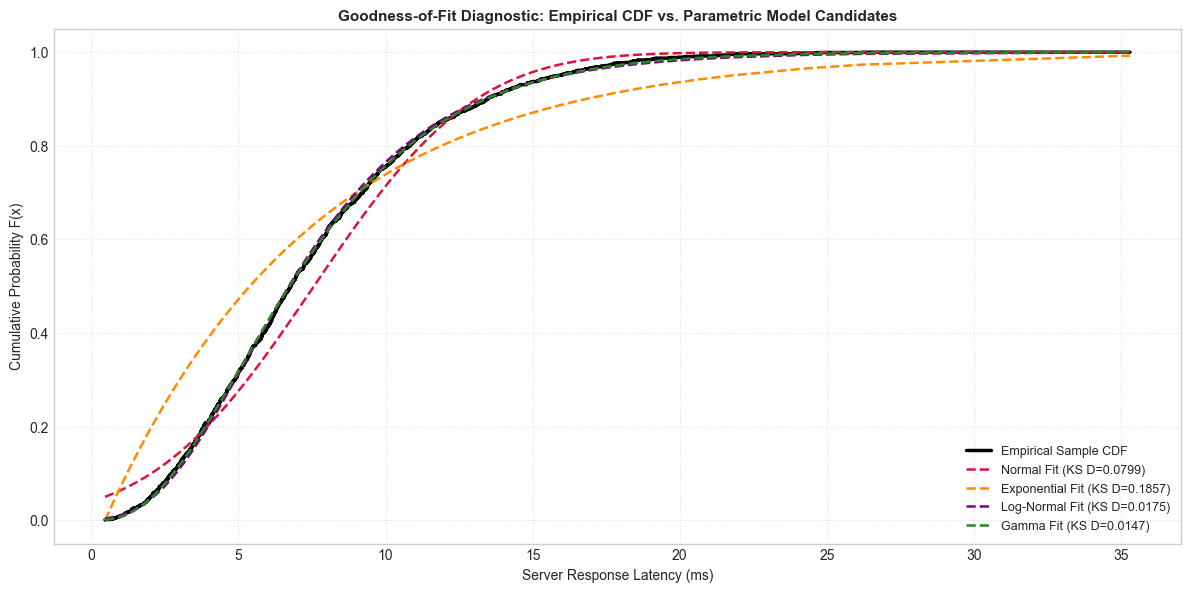

In [13]:
# ==============================================================================
# SECTION 6 CODE: EMPIRICAL DISTRIBUTION FITTING & K-S BENCHMARK
# ==============================================================================
# 1. Generate an unknown empirical dataset (Synthetic server response latency in a microservices mesh)
# True underlying generator: Gamma(shape=3.0, scale=2.5)
true_shape, true_scale = 3.0, 2.5
empirical_latency = rng.gamma(shape=true_shape, scale=true_scale, size=1500)

# 2. Fit 4 Candidate Continuous Models via MLE
candidates = {
    'Normal': stats.norm,
    'Exponential': stats.expon,
    'Log-Normal': stats.lognorm,
    'Gamma': stats.gamma
}

ks_results = []
fitted_params = {}

for name, dist_obj in candidates.items():
    # Fit parameters via MLE
    params = dist_obj.fit(empirical_latency)
    fitted_params[name] = params
    
    # Run Kolmogorov-Smirnov Test
    ks_stat, p_val = stats.kstest(empirical_latency, dist_obj.name, args=params)
    
    ks_results.append({
        'Candidate Model': name,
        'K-S Statistic (D)': ks_stat,
        'p-value': p_val,
        'Verdict (alpha=0.05)': 'Accept H0 (Excellent Fit)' if p_val > 0.05 else 'Reject H0 (Poor Fit)'
    })

ks_df = pd.DataFrame(ks_results).sort_values('K-S Statistic (D)')

print("=" * 85)
print("         KOLMOGOROV-SMIRNOV GOODNESS-OF-FIT BENCHMARK FOR EMPIRICAL DATA        ")
print("=" * 85)
print(ks_df.to_string(index=False, float_format=lambda x: f"{x:10.5f}"))
print("=" * 85)
best_model = ks_df.iloc[0]['Candidate Model']
print(f"\nOptimal Model Selected by Minimum K-S Discrepancy: >>> {best_model} <<<")
print(f"Fitted Gamma Parameters: Shape = {fitted_params['Gamma'][0]:.3f} (True: {true_shape}), Scale = {fitted_params['Gamma'][2]:.3f} (True: {true_scale})")

# 3. Visual Diagnostic: Empirical CDF vs. Candidate CDFs
x_eval_ks = np.sort(empirical_latency)
empirical_cdf = np.arange(1, len(x_eval_ks) + 1) / len(x_eval_ks)

plt.figure(figsize=(12, 6))
plt.step(x_eval_ks, empirical_cdf, color='black', lw=2.5, label='Empirical Sample CDF')

colors_fit = {'Normal': 'crimson', 'Exponential': 'darkorange', 'Log-Normal': 'purple', 'Gamma': 'forestgreen'}
for name, dist_obj in candidates.items():
    cdf_fit = dist_obj.cdf(x_eval_ks, *fitted_params[name])
    plt.plot(x_eval_ks, cdf_fit, color=colors_fit[name], lw=1.8, linestyle='--',
             label=f"{name} Fit (KS D={ks_df.loc[ks_df['Candidate Model']==name, 'K-S Statistic (D)'].values[0]:.4f})")

plt.title('Goodness-of-Fit Diagnostic: Empirical CDF vs. Parametric Model Candidates', fontweight='bold')
plt.xlabel('Server Response Latency (ms)')
plt.ylabel('Cumulative Probability F(x)')
plt.legend(fontsize=9, loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 7. Master Enterprise Matrix: Where & Why Continuous Distributions are Used

| Distribution | NumPy / SciPy API | Industry Sector | Specific Real-World Enterprise Use Case |
| :--- | :--- | :--- | :--- |
| **Normal (Gaussian)** | `rng.normal()`<br>`stats.norm` | **Manufacturing & AI** | **Six Sigma Quality Control (GE, Motorola):** Parts tolerance monitoring ($<3.4$ defects per million at $6\sigma$). OLS regression residuals, Gaussian Naive Bayes. |
| **Standard Normal $\mathcal{Z}$** | `stats.norm(0, 1)` | **Data Engineering** | **`StandardScaler()` feature normalization:** Z-scores ($|Z| > 3$) for automated fraud alerts and data sanitization. |
| **Continuous Uniform** | `rng.uniform()`<br>`stats.uniform` | **Machine Learning** | **`RandomizedSearchCV` Hyperparameter Tuning:** Baseline non-informative prior; random generation for Monte Carlo simulations. |
| **Exponential** | `rng.exponential()`<br>`stats.expon` | **Cloud Computing & SRE** | **Mean Time Between Failures (MTBF):** Modeling server failure intervals at AWS/Google Cloud; customer service call center queue wait times. |
| **Gamma** | `rng.gamma()`<br>`stats.gamma` | **Fintech & Telecom** | **Multi-stage queuing latency & Insurance Claims:** Aggregate claim payouts; Bayesian conjugate prior for Poisson customer arrival rates. |
| **Weibull** | `rng.weibull()`<br>`stats.weibull_min` | **Aerospace & Energy** | **Jet Engine & Wind Turbine Reliability (Boeing, GE):** Bathtub curve failure forecasting (infant mortality $k<1$, aging wear-out $k>1$). |
| **Log-Normal** | `rng.lognormal()`<br>`stats.lognorm` | **Quant Finance & Tech** | **Black-Scholes Stock Options & API Latency:** Stock prices (cannot be negative; compound multiplicatively); Netflix p95/p99 streaming latency. |
| **Pareto (Power-Law)** | `rng.pareto()`<br>`stats.pareto` | **E-Commerce & Cyber** | **The 80/20 Rule (Amazon):** $80\%$ of revenue generated by $20\%$ of products; DDoS attack packet volume bursts; catastrophic natural disasters. |
| **Student's t** | `rng.standard_t()`<br>`stats.t` | **Product Analytics & AI** | **Small-sample A/B Testing ($n < 30$):** Heavy-tail risk modeling for hedge funds; **t-SNE** non-linear dimensionality reduction. |
| **Chi-Square ($\chi^2$)** | `rng.chisquare()`<br>`stats.chi2` | **Feature Selection** | **Scikit-Learn `SelectKBest(chi2)`:** Testing dependence between categorical input features and targets; survey independence contingency testing. |
| **Fisher's F** | `rng.f()`<br>`stats.f` | **Healthcare & Analytics** | **ANOVA & Regression Significance:** Comparing efficacy across $>2$ clinical drug treatment groups simultaneously; testing overall $R^2$ significance. |
| **Beta** | `rng.beta()`<br>`stats.beta` | **AdTech & E-Commerce** | **Thompson Sampling Multi-Armed Bandits:** Bounded support $[0, 1]$ for real-time click-through rate (CTR) optimization and Bayesian A/B testing. |
| **Triangular** | `rng.triangular()`<br>`stats.triang` | **Project Management** | **PERT / CPM Risk Simulation:** Three-point estimation (Optimistic $a$, Mode $c$, Pessimistic $b$) for construction and defense contract timelines. |
| **Laplace (Double Exp)** | `rng.laplace()`<br>`stats.laplace` | **Cybersecurity & ML** | **L1 Lasso Regularization Prior:** Drives non-essential weights to zero. **Differential Privacy (Apple, Google):** Calibrated noise injection for user privacy. |
| **Cauchy (Lorentzian)** | `stats.cauchy` | **Physics & Stress-Testing** | **Algorithmic Stress-Testing:** Worst-case scenario testing with undefined variance; resonance absorption profiles in nuclear spectroscopy. |
| **Logistic** | `rng.logistic()`<br>`stats.logistic` | **Gaming & Classification** | **Logistic Regression Link Function:** Sigmoid activation in neural networks; **Elo Rating System** in Chess, FIFA, and competitive esports. |